# Active Learning Sampling Map

This notebook reproduces the PCA map comparing active sampling and random sampling. It uses cached plotting source data from `paper/data/Fig_active_learning_sampling/` when available. Cached files are keyed by `SAMPLE_VIRUS_SIZE`, so changing the sample size produces a separate source-data file and figure. If the matching cache is missing, or if `FORCE_REBUILD = True`, it rebuilds the plotting source data from the active-learning dataset, sequence embeddings, and pretrained checkpoint.

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


SAMPLE_VIRUS_SIZE = 50
RANDOM_STATE = 42
FORCE_REBUILD = False


def find_project_root(start=None):
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / "src" / "fluprofiler" / "utilities.py").exists():
            return path
    raise RuntimeError(f"Cannot find project root from: {current}")


def configure_import_paths(project_root):
    for path in [project_root / "src", project_root / "src" / "fluprofiler"]:
        path_str = str(path)
        if path_str not in sys.path:
            sys.path.insert(0, path_str)


def register_legacy_model_module():
    if "fluProfiler_models" in sys.modules:
        del sys.modules["fluProfiler_models"]
    importlib.invalidate_caches()
    old_mod = importlib.import_module("fluProfiler_models")
    sys.modules["fluProfiler_models"] = old_mod


project_root = find_project_root()
configure_import_paths(project_root)
register_legacy_model_module()

from utilities import load_embedding


data_csv = project_root / "data" / "active_learning" / "processed" / "All.csv"
embedding_dir = project_root / "data" / "reverse_test" / "embedding"
checkpoint_path = project_root / "runs" / "holdout_tests" / "titer" / "2025-08-19_17-43-32.pth"

source_dir = project_root / "paper" / "data" / "Fig_active_learning_sampling"
source_npz = source_dir / f"active_learning_sampling_map_{SAMPLE_VIRUS_SIZE}.npz"
active_selected_csv = source_dir / f"active_selected_{SAMPLE_VIRUS_SIZE}.csv"
random_selected_csv = source_dir / f"random_selected_{SAMPLE_VIRUS_SIZE}.csv"

figure_dir = project_root / "paper" / "Figure"
figure_png = figure_dir / f"active_learning_sampling_map_{SAMPLE_VIRUS_SIZE}.png"
figure_svg = figure_dir / f"active_learning_sampling_map_{SAMPLE_VIRUS_SIZE}.svg"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def group_and_filter(df):
    group_columns = ["seq_a", "seq_b", "seq_c", "seq_d", "serumPassCat", "virusPassCat"]
    agg_dict = {col: "first" for col in df.columns if col not in group_columns}
    agg_dict["label"] = "mean"
    return df.groupby(group_columns).agg(agg_dict).reset_index()


class Emb2Vec(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.matrix_dropout = model.matrix_dropout
        self.matrix_pooler = model.matrix_pooler
        self.linear = model.linear[0][0]

    def forward(self, embedding):
        embedding = self.matrix_dropout(embedding)
        seq_vector = self.matrix_pooler(embedding)
        return self.linear(seq_vector)


def run_emb2vec_on_dict(emb_dict, emb2vec, device):
    emb2vec = emb2vec.to(device)
    emb2vec.eval()

    vec_dict = {}
    for key, emb in emb_dict.items():
        emb = emb.to(device)
        if emb.dim() == 2:
            emb = emb.unsqueeze(0)
        with torch.no_grad():
            vec_dict[key] = emb2vec(emb)[0].cpu()
    return vec_dict


def select_representative_viruses(virus_emb, n_clusters):
    if n_clusters > len(virus_emb):
        raise ValueError(f"n_clusters={n_clusters} exceeds available viruses={len(virus_emb)}")

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10).fit(virus_emb)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    selected_indices = []
    for cluster_id in range(n_clusters):
        idx = np.where(labels == cluster_id)[0]
        if len(idx) == 0:
            continue
        cluster_points = virus_emb[idx]
        distances = np.linalg.norm(cluster_points - centers[cluster_id], axis=1)
        selected_indices.append(idx[np.argmin(distances)])
    return selected_indices


def sample_keep_one_per_virus(df, target_n, virus_cols=("seq_id_c", "seq_id_d")):
    shuffled = df.sample(frac=1, random_state=RANDOM_STATE)
    one_per_virus = shuffled.drop_duplicates(subset=list(virus_cols), keep="first")

    if target_n < len(one_per_virus):
        raise ValueError(
            f"target_n={target_n} is smaller than selected virus groups={len(one_per_virus)}"
        )

    remain_n = target_n - len(one_per_virus)
    if remain_n == 0:
        return one_per_virus.reset_index(drop=True)

    remaining_pool = shuffled.drop(index=one_per_virus.index)
    if remain_n > len(remaining_pool):
        raise ValueError("Not enough remaining samples to reach target_n")

    extra = remaining_pool.sample(n=remain_n, random_state=RANDOM_STATE)
    out = pd.concat([one_per_virus, extra], axis=0)
    return out.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


def load_active_learning_candidates():
    all_data = pd.read_csv(data_csv)
    season_number = all_data["sheet"].str.split("-").str[0].astype(int)
    active_final = all_data[(season_number >= 41) & (season_number <= 42)]
    active_final = group_and_filter(active_final)
    active_candidate, _ = train_test_split(active_final, test_size=0.1, random_state=RANDOM_STATE)
    return active_final, active_candidate


def load_required_embeddings(active_final):
    emb_files = "matrix_" + pd.concat(
        [
            active_final["seq_id_a"],
            active_final["seq_id_b"],
            active_final["seq_id_c"],
            active_final["seq_id_d"],
        ]
    ).drop_duplicates() + ".pt"
    return load_embedding(path=str(embedding_dir), files=emb_files, map_location=device)


def build_virus_matrix(active_candidate, vector_dict):
    virus_vectors = []
    for row in active_candidate.itertuples():
        ha_vector = vector_dict["matrix_" + row.seq_id_c]
        na_vector = vector_dict["matrix_" + row.seq_id_d]
        virus_vectors.append(torch.cat([ha_vector, na_vector], dim=0))
    return torch.stack(virus_vectors).detach().cpu().numpy()


def choose_active_and_random_samples(active_candidate, X):
    unique_virus_emb, selected_indices = np.unique(X, axis=0, return_index=True)
    virus_df = active_candidate.copy().reset_index(drop=True).iloc[selected_indices]

    active_selected_virus = select_representative_viruses(
        unique_virus_emb, n_clusters=SAMPLE_VIRUS_SIZE
    )
    active_selected = virus_df.iloc[active_selected_virus][["seq_id_c", "seq_id_d"]].merge(
        active_candidate, on=["seq_id_c", "seq_id_d"], how="left"
    )

    random_selected_virus = virus_df.sample(len(active_selected_virus), random_state=RANDOM_STATE)
    random_selected = random_selected_virus[["seq_id_c", "seq_id_d"]].merge(
        active_candidate, on=["seq_id_c", "seq_id_d"], how="left"
    )

    target_n = min(len(active_selected), len(random_selected))
    active_selected = sample_keep_one_per_virus(active_selected, target_n)
    random_selected = sample_keep_one_per_virus(random_selected, target_n)

    active_rows_in_X = np.asarray(selected_indices, dtype=int)[
        np.asarray(active_selected_virus, dtype=int)
    ]
    random_idx_pos = virus_df.index.get_indexer(random_selected_virus.index)
    if (random_idx_pos < 0).any():
        raise ValueError("random_selected_virus.index contains labels not found in virus_df.index")
    random_rows_in_X = np.asarray(selected_indices, dtype=int)[random_idx_pos]

    return active_selected, random_selected, active_rows_in_X, random_rows_in_X


def ensure_required_files_exist():
    for required_path in [data_csv, embedding_dir, checkpoint_path]:
        if not required_path.exists():
            raise FileNotFoundError(required_path)


def build_plot_source():
    ensure_required_files_exist()
    source_dir.mkdir(parents=True, exist_ok=True)

    active_final, active_candidate = load_active_learning_candidates()
    emb_dict = load_required_embeddings(active_final)
    model = torch.load(checkpoint_path, weights_only=False, map_location=device)
    vector_dict = run_emb2vec_on_dict(emb_dict, Emb2Vec(model), device=device)
    X = build_virus_matrix(active_candidate, vector_dict)

    active_selected, random_selected, active_rows_in_X, random_rows_in_X = choose_active_and_random_samples(
        active_candidate, X
    )

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca.fit_transform(X)

    active_selected.to_csv(active_selected_csv, index=False)
    random_selected.to_csv(random_selected_csv, index=False)
    np.savez_compressed(
        source_npz,
        X_2d=X_2d,
        active_rows_in_X=active_rows_in_X,
        random_rows_in_X=random_rows_in_X,
        explained_variance_ratio=pca.explained_variance_ratio_,
        sample_virus_size=np.array(SAMPLE_VIRUS_SIZE),
        active_selection_size=np.array(len(active_selected)),
        random_selection_size=np.array(len(random_selected)),
    )
    return np.load(source_npz)


def load_or_build_plot_source():
    if source_npz.exists() and not FORCE_REBUILD:
        print(f"Loaded cached plotting source data: {source_npz}")
        return np.load(source_npz)

    data = build_plot_source()
    print(f"Built and saved plotting source data: {source_npz}")
    return data


def summarize_plot_source(data):
    explained_variance_ratio = data["explained_variance_ratio"]
    print(f"Project root: {project_root}")
    print(f"Device: {device}")
    print(f"Sample virus size: {int(data['sample_virus_size'])}")
    print(f"PCA shape: {data['X_2d'].shape}")
    print(f"Explained variance ratio: {explained_variance_ratio}")
    print(f"Cumulative explained variance: {explained_variance_ratio.sum():.4f}")
    print(f"Active selected rows: {len(data['active_rows_in_X'])}")
    print(f"Random selected rows: {len(data['random_rows_in_X'])}")


def plot_sampling_map(data):
    X_2d = data["X_2d"]
    active_rows_in_X = data["active_rows_in_X"]
    random_rows_in_X = data["random_rows_in_X"]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.35, c="lightgray", label="All strains")
    ax.scatter(
        X_2d[random_rows_in_X, 0],
        X_2d[random_rows_in_X, 1],
        s=22,
        c="blue",
        alpha=0.85,
        label="Random sampling",
    )
    ax.scatter(
        X_2d[active_rows_in_X, 0],
        X_2d[active_rows_in_X, 1],
        s=22,
        c="red",
        alpha=0.90,
        label="Active sampling",
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    return fig, ax


def save_figure(fig):
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_png, dpi=600, bbox_inches="tight")
    fig.savefig(figure_svg, bbox_inches="tight")
    print(f"Saved: {figure_png}")
    print(f"Saved: {figure_svg}")

In [2]:
plot_data = load_or_build_plot_source()
summarize_plot_source(plot_data)

Loading tensor: 100%|██████████| 1555/1555 [00:58<00:00, 26.51file/s]


Built and saved plotting source data: /home/chenyh/workspace/fluProfiler/paper/data/Fig_active_learning_sampling/active_learning_sampling_map_50.npz
Project root: /home/chenyh/workspace/fluProfiler
Device: cuda:0
Sample virus size: 50
PCA shape: (9115, 2)
Explained variance ratio: [0.6963581  0.04063009]
Cumulative explained variance: 0.7370
Active selected rows: 50
Random selected rows: 50


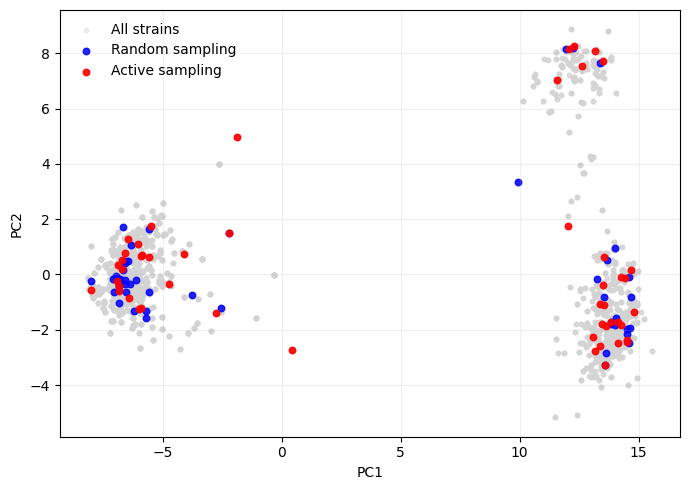

In [3]:
fig, ax = plot_sampling_map(plot_data)
# save_figure(fig)
plt.show()